PyTorch의 nn.LSTM을 사용한 멀티레이어 양방향 LSTM 모델의 예제이며,

In [3]:
import torch
from torch import nn


In [4]:
input_size = 128         # 입력 feature 벡터 크기
output_size = 256        # LSTM hidden state 크기
num_layers = 3           # LSTM 층 수 (3층)
bidirectional = True     # 양방향 LSTM
proj_size = 64           # Projection output 차원


In [5]:
model = nn.LSTM(
    input_size=128,
    hidden_size=256,
    num_layers=3,
    batch_first=True,
    bidirectional=True,
    proj_size=64,
)


In [7]:
""" 입력은 (batch, seq_len, input_size)
내부적으로 각 LSTM layer는 다음을 처리함:
내부 상태 크기: hidden_size = 256
출력 projection 크기: proj_size = 64

양방향이므로:

각 시퀀스에 대해 forward & backward 방향의 LSTM이 따로 작동
출력은 두 방향 결과를 concat한 형태

 """

' 입력은 (batch, seq_len, input_size)\n내부적으로 각 LSTM layer는 다음을 처리함:\n내부 상태 크기: hidden_size = 256\n출력 projection 크기: proj_size = 64\n\n양방향이므로:\n\n각 시퀀스에 대해 forward & backward 방향의 LSTM이 따로 작동\n출력은 두 방향 결과를 concat한 형태\n\n '

In [8]:
inputs = torch.randn(4, 6, 128)  # (batch_size=4, seq_len=6, input_dim=128)
h_0 = torch.rand(6, 4, 64)  # (num_layers * num_directions, batch, proj_size)
c_0 = torch.rand(6, 4, 256) # (num_layers * num_directions, batch, hidden_size)

""" 
h_0은 projection된 차원(64)
c_0은 여전히 원래 hidden_size(256) 사용 (projection 이전 값이므로)
"""

' \nh_0은 projection된 차원(64)\nc_0은 여전히 원래 hidden_size(256) 사용 (projection 이전 값이므로)\n'

In [ ]:
outputs, (h_n, c_n) = model(inputs, (h_0, c_0))

print(outputs.shape)  # ➜ (4, 6, 128)
""" 
(batch_size, seq_len, proj_size * 2)
왜 128? → proj_size = 64 이고, 양방향이니까 64 x 2 = 128
"""
print(h_n.shape)  # ➜ (6, 4, 64) (num_layers * num_directions, batch_size, proj_size)
print(c_n.shape)  # ➜ (6, 4, 256)


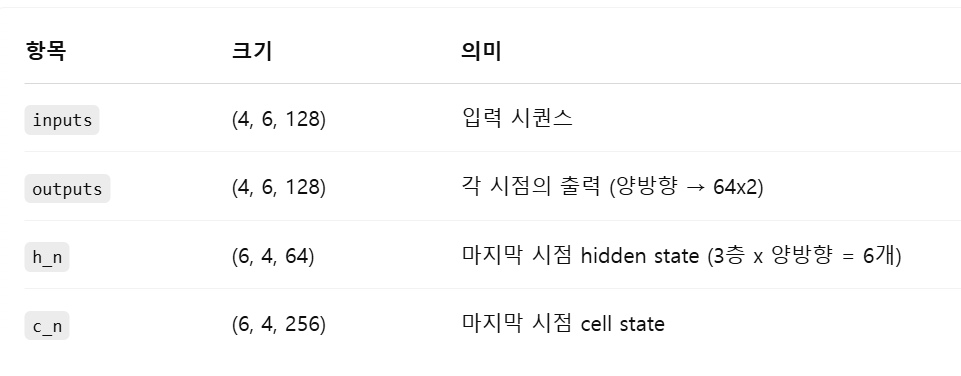

#### proj_size란?
- PyTorch의 LSTM은 hidden state의 크기를 줄이기 위해 projection layer를 옵션으로 제공함.
- proj_size 설정 시, LSTM 내부에서는 hidden_size로 연산하고 마지막에 proj_size로 줄여서 출력.
- 계산량과 메모리를 줄이면서도 깊은 RNN을 구성할 수 있음.

text 데이터를 분석하는 
Custom RNN 모델을 만들기 위해서

1. raw data 정제
	- 특수문자처리 #불용어 nltk.corpus
	- 표제어 # WordNetLemmatizer
	- 형태소 #Okt, kkoma, etc..
			#Spacy.load(model)
	- 토큰화 #nltk.tokenize 
	- 구두점 # PUNCTUATION

2. 데이터셋 만들기
	- vocab 만들기 => 단어 인덱싱
					# VOCAB_TO_IDX = {'<PAD>':0, '<UNK>':1 }
	- 숫자로 변환 => 인코딩 OneHotEncoder  희소행렬Sparse
					=> 해결위해 임베딩 Dense로
	- DS, DL 만들기

3. 커스텀 RNN 만들기
	- 입력층 크기
	- 출력층 크기(히든층) * 양방향 구성시 크기 2배
	- 층 개수
	- 배치 퍼스트 TF
	- 양방향 TF
	- pj 크기 => 히든 state의 크기를 줄이기 위해 제공되는 최종 레이어
